In [1]:
# 1. INTRODUCTION
#Analyse des ventes pharmaceutiques pour comprendre la performance des pharmacies,
#la consommation des patients et la chaîne logistique.

In [2]:
# 2. IMPORTS & DATA LOADING

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import os
os.makedirs("resultats", exist_ok=True)
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)

os.makedirs("resultats", exist_ok=True)

In [4]:
conn = sqlite3.connect("new_pharmaci.db")

df = pd.read_sql_query("""
SELECT
    v.id_vente,
    r.nom_region AS region,
    vi.nom_ville AS ville,
    pa.nom AS patient,
    p.nom AS pharmacie,
    p.id_grossiste,   
    m.nom AS medicament,
    m.categorie,
    v.quantite,
    v.prix_vente,
    v.date_vente,
    v.saison,
    m.pfht,
    p.stock,
    p.marge
FROM ventes v
JOIN patients pa    ON v.id_patient    = pa.id_patient
JOIN pharmacies p   ON v.id_pharmacie  = p.id_pharmacie
JOIN villes vi      ON p.id_ville      = vi.id_ville
JOIN regions r      ON vi.id_region    = r.id_region
JOIN medicaments m  ON v.id_medicament = m.id_medicament
""", conn)

df.head()

,id_vente,region,ville,patient,pharmacie,id_grossiste,medicament,categorie,quantite,prix_vente,date_vente,saison,pfht,stock,marge
0,1,Rabat-Salé-Kénitra,Rabat,Patient_Rabat_1,Pharmacie Rabat 2,1,Paracétamol 100mg susp (45),T1,1,114.44,2024-09-26,printemps/automne,85.45,1386,30.32
1,2,Rabat-Salé-Kénitra,Rabat,Patient_Rabat_1,Pharmacie Rabat 2,1,Amoxicilline 50mg inj (12),T1,2,75.27,2024-02-06,hiver,28.10,1386,30.32
2,3,Rabat-Salé-Kénitra,Rabat,Patient_Rabat_1,Pharmacie Rabat 2,1,Trastuzumab 50mg sol (7),T3,1,1684.83,2024-10-01,printemps/automne,1384.83,1386,30.32
3,4,Rabat-Salé-Kénitra,Rabat,Patient_Rabat_1,Pharmacie Rabat 2,1,Atorvastatine 10mg patch (13),T2,1,663.43,2024-01-16,hiver,511.35,1386,30.32
4,5,Rabat-Salé-Kénitra,Rabat,Patient_Rabat_1,Pharmacie Rabat 2,1,Vitamine C 40mg crème (3),T1,1,138.15,2024-03-23,printemps/automne,103.15,1386,30.32


In [5]:
# =========================
# 3. FEATURE ENGINEERING
# =========================

In [6]:
df["ca"] = df["prix_vente"]

df["cout"] = df["pfht"] * df["quantite"]

df["profit"] = df["ca"] - df["cout"]

df["prix_unitaire"] = df["ca"] / df["quantite"]

df["marge_unitaire"] = df["prix_unitaire"] - df["pfht"]

df["taux_marge"] = (df["marge_unitaire"] / df["pfht"]) * 100


In [7]:
print("CA total :", df["ca"].sum())
print("Profit total :", df["profit"].sum())
print("Nombre ventes :", df["id_vente"].count())
print("Panier moyen :", df["ca"].mean())

CA total : 908799.52
Profit total : 200128.88
Nombre ventes : 2715
Panier moyen : 334.732788213628


In [8]:
# =========================
# 4. EDA (EXPLORATION)
# =========================

In [9]:
print("SHAPE :", df.shape)
print("\nMissing values :\n", df.isnull().sum())
print("\nDescription :\n", df.describe())

SHAPE : (2715, 21)

Missing values :
 id_vente          0
region            0
ville             0
patient           0
pharmacie         0
id_grossiste      0
medicament        0
categorie         0
quantite          0
prix_vente        0
date_vente        0
saison            0
pfht              0
stock             0
marge             0
ca                0
cout              0
profit            0
prix_unitaire     0
marge_unitaire    0
taux_marge        0
dtype: int64

Description :
           id_vente  id_grossiste     quantite    prix_vente         pfht  \
count  2715.000000   2715.000000  2715.000000   2715.000000  2715.000000   
mean   1358.000000      1.935175     1.351013    334.732788   194.564545   
std     783.897315      0.671724     0.574092    622.916368   357.611130   
min       1.000000      1.000000     1.000000     11.330000     8.460000   
25%     679.500000      1.000000     1.000000     93.835000    59.490000   
50%    1358.000000      2.000000     1.000000    170.8900

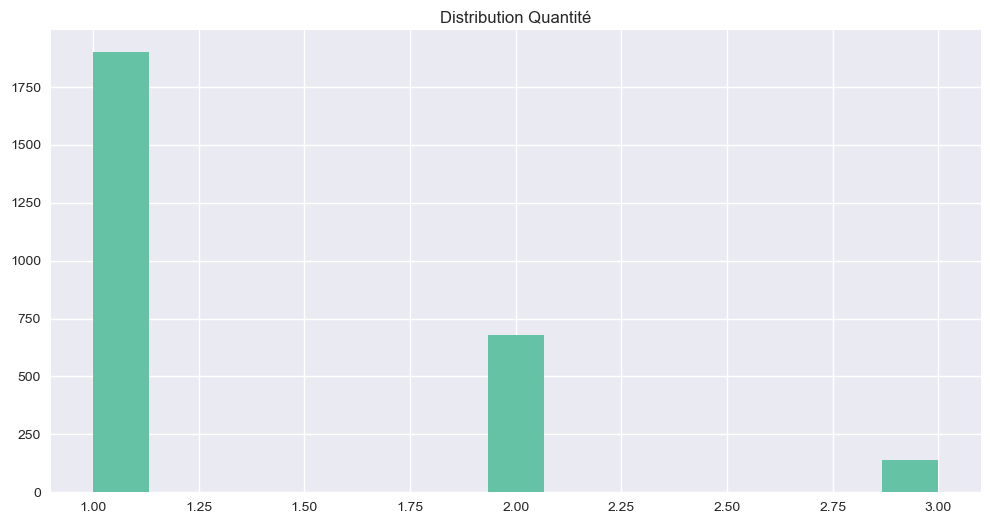

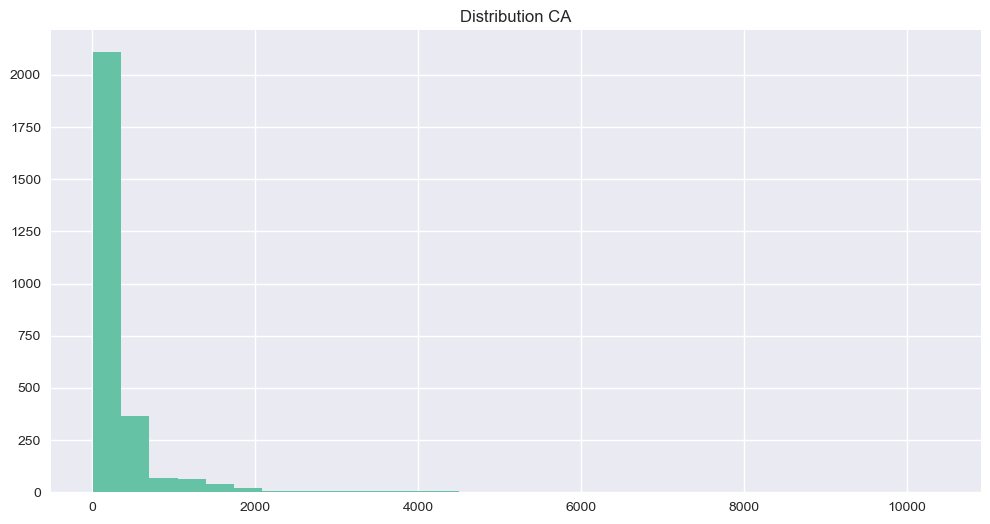

In [10]:
#distributions
plt.hist(df["quantite"], bins=15)
plt.title("Distribution Quantité")
plt.savefig("resultats/distribution_quantite.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["ca"], bins=30)
plt.title("Distribution CA")
plt.savefig("resultats/distribution_ca.png", dpi=300, bbox_inches="tight")
plt.show()

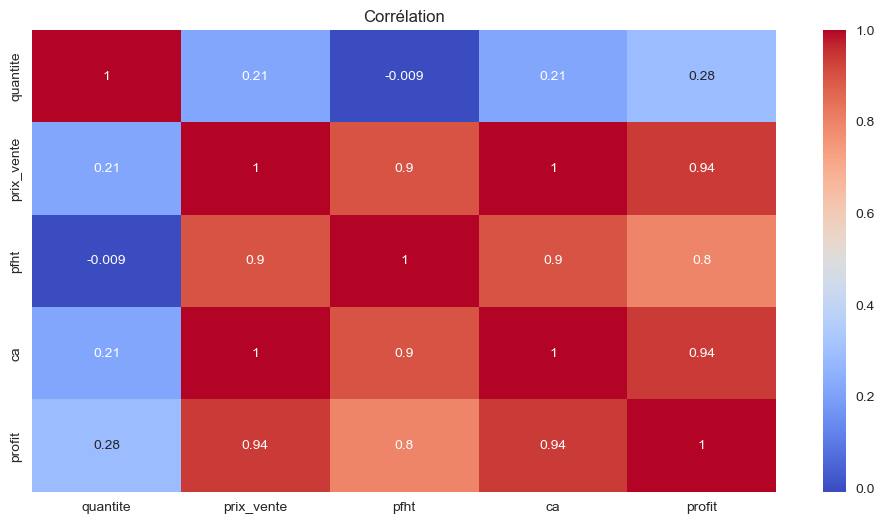

In [11]:
#  CORRELATION
cols = ["quantite", "prix_vente", "pfht", "ca", "profit"]
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation")
plt.savefig("resultats/correlation.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# =========================
# 5. BUSINESS ANALYSIS
# =========================

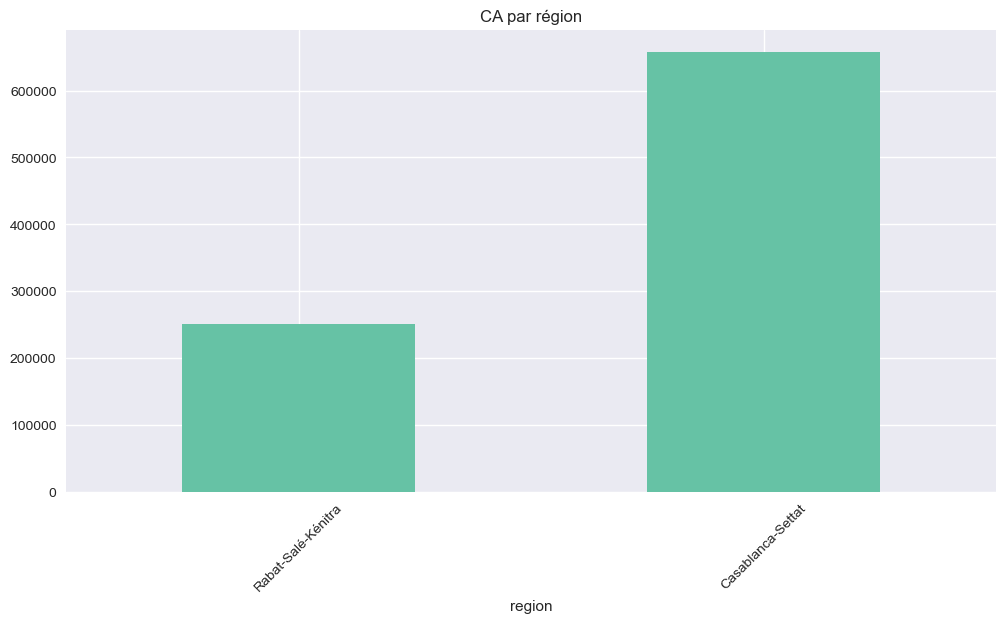

In [13]:
#Ventes géographiques
#CA par région
df.groupby("region")["ca"].sum().sort_values().plot(kind="bar")
plt.title("CA par région")
plt.xticks(rotation=45)
plt.savefig("resultats/ca_region.png", dpi=300, bbox_inches="tight")
plt.show()


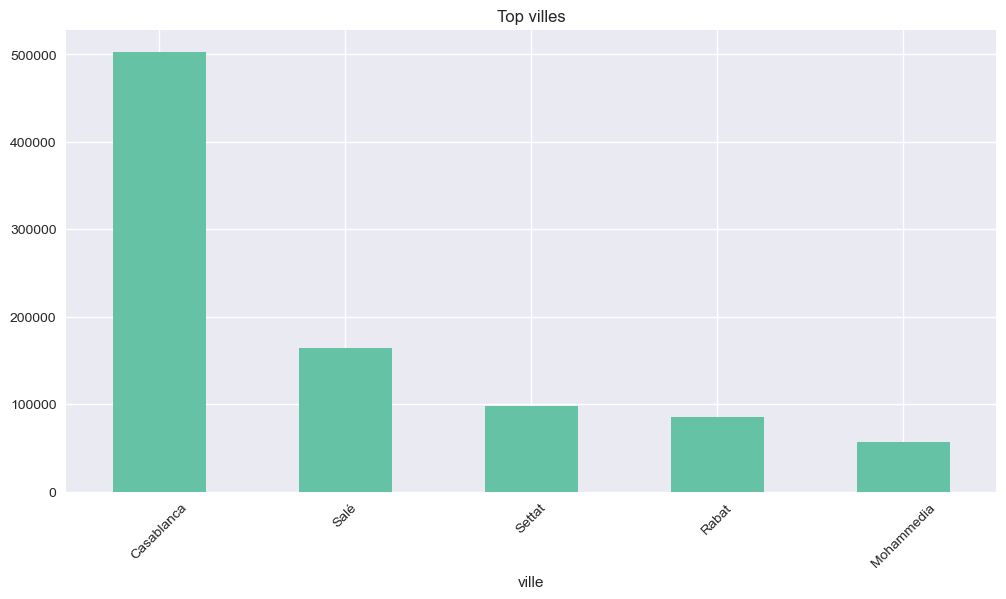

In [14]:
#CA par ville
df.groupby("ville")["ca"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top villes")
plt.xticks(rotation=45)
plt.savefig("resultats/top_villes.png", dpi=300, bbox_inches="tight")
plt.show()

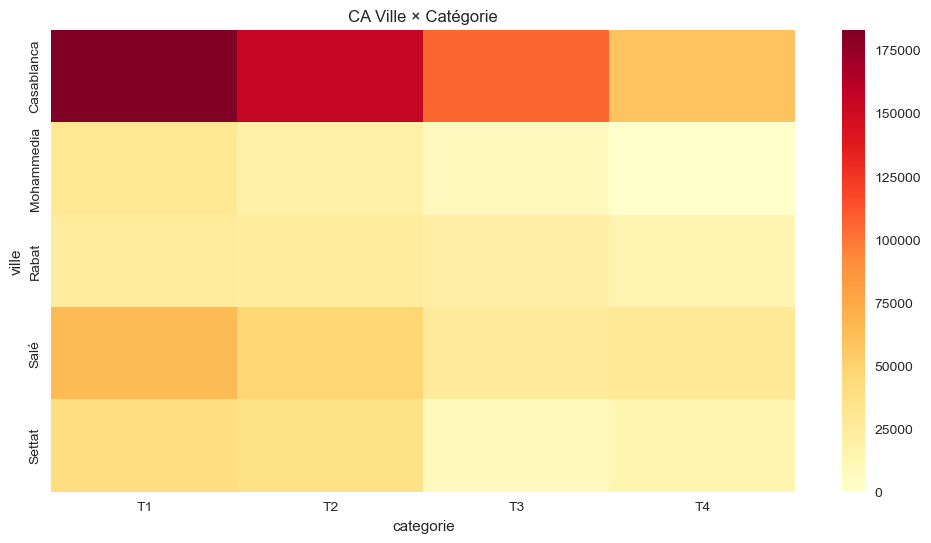

In [15]:
pivot = df.pivot_table(
    index="ville",
    columns="categorie",
    values="ca",
    aggfunc="sum",
    fill_value=0
)

sns.heatmap(pivot, cmap="YlOrRd")
plt.title("CA Ville × Catégorie")
plt.savefig("resultats/heatmap_ville_categorie.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
#Produits

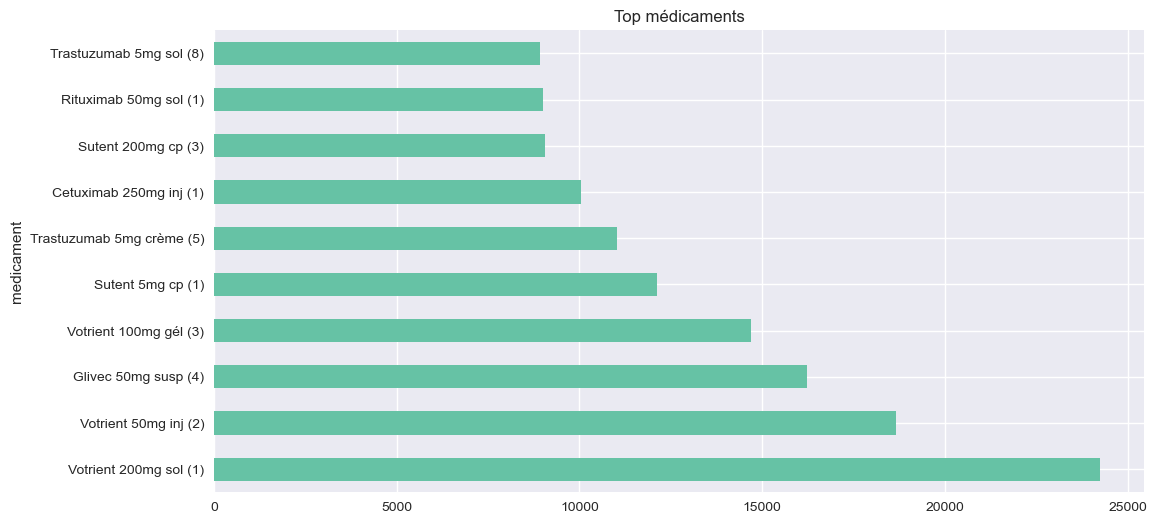

In [17]:
df.groupby("medicament")["ca"].sum().sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top médicaments")
plt.savefig("resultats/top_medicaments.png", dpi=300, bbox_inches="tight")
plt.show()

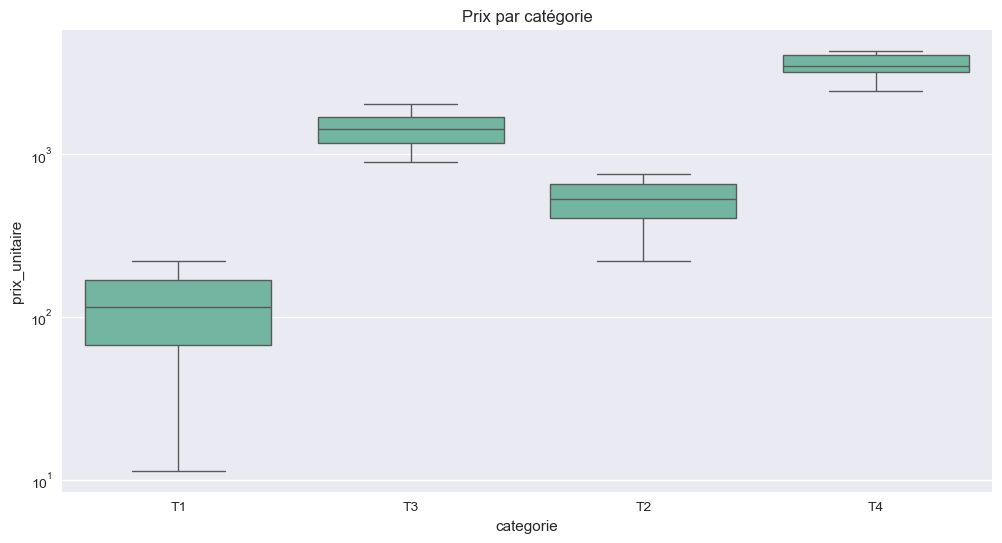

In [18]:
sns.boxplot(data=df, x="categorie", y="prix_unitaire")
plt.yscale("log")
plt.title("Prix par catégorie")
plt.savefig("resultats/prix_categorie.png", dpi=300, bbox_inches="tight")
plt.show()

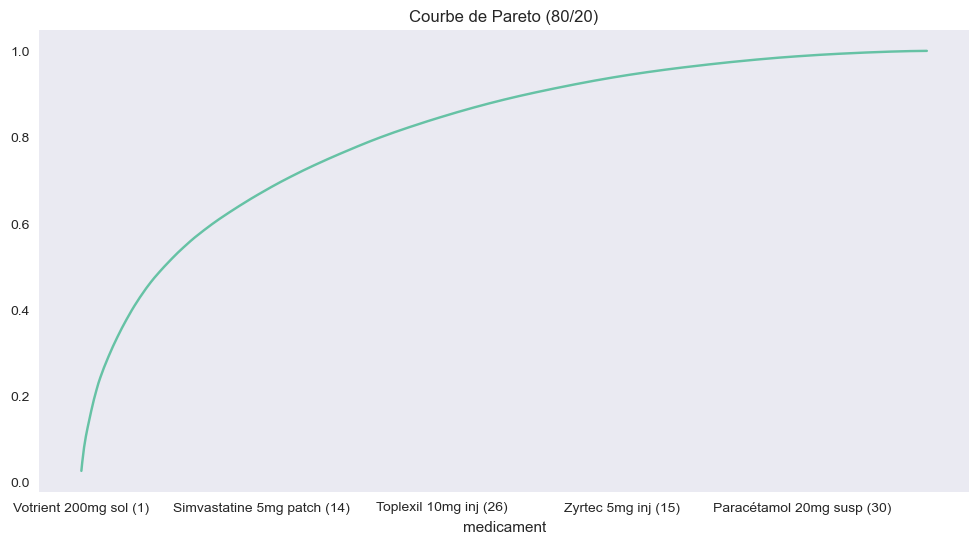

In [19]:
pareto = df.groupby("medicament")["ca"].sum().sort_values(ascending=False)
pareto_cumsum = pareto.cumsum() / pareto.sum()

pareto_cumsum.plot()
plt.title("Courbe de Pareto (80/20)")
plt.grid()
plt.savefig("resultats/pareto.png", dpi=300, bbox_inches="tight")
plt.show()

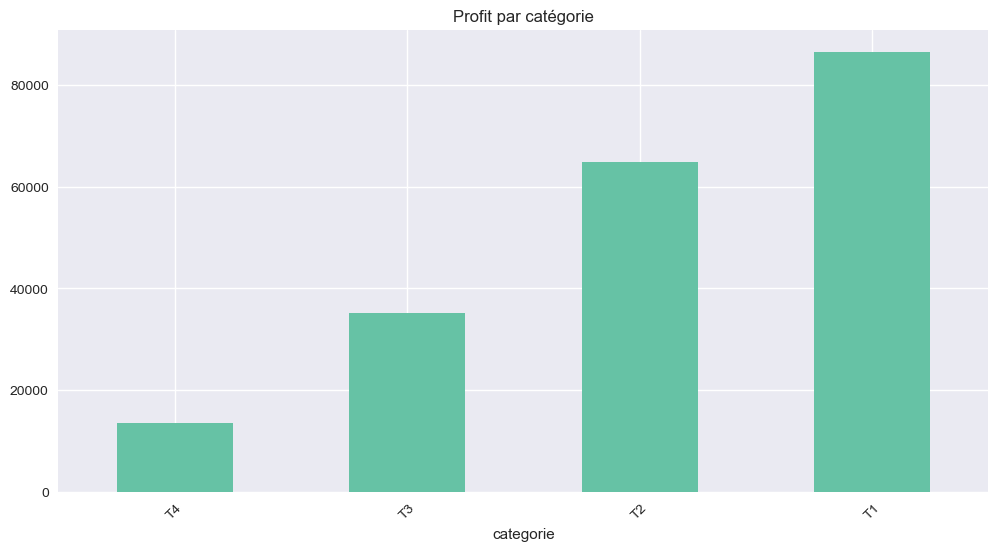

In [20]:
df.groupby("categorie")["profit"].sum().sort_values().plot(kind="bar")
plt.title("Profit par catégorie")
plt.xticks(rotation=45)
plt.savefig("resultats/profit_categorie.png", dpi=300, bbox_inches="tight")
plt.show()

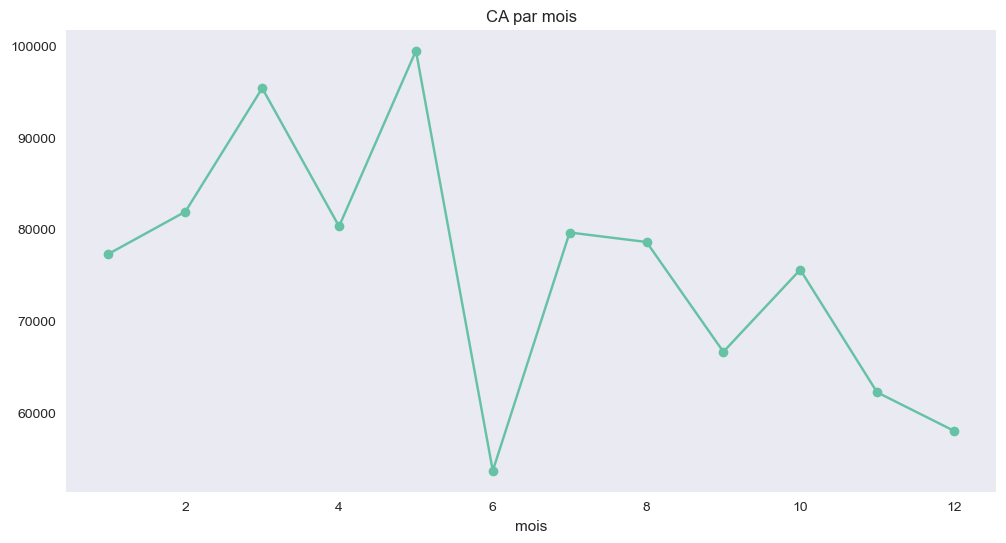

In [21]:
#Temps
#CA par mois
df["date_vente"] = pd.to_datetime(df["date_vente"])
df["mois"] = df["date_vente"].dt.month

df.groupby("mois")["ca"].sum().plot(marker="o")
plt.title("CA par mois")
plt.grid()
plt.savefig("resultats/ca_mois.png", dpi=300, bbox_inches="tight")
plt.show()

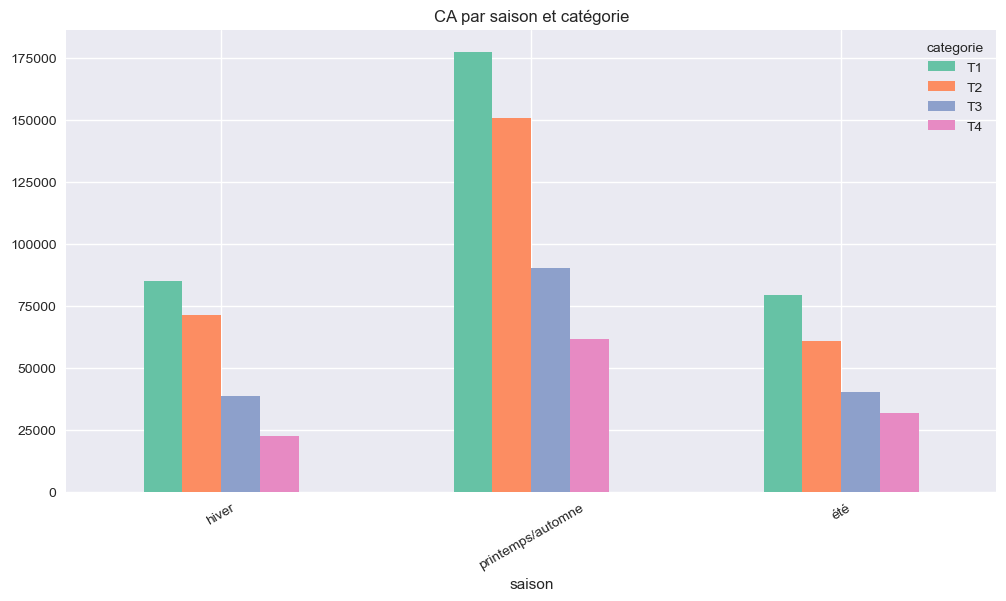

In [22]:
df.groupby(["saison", "categorie"])["ca"].sum().unstack().plot(kind="bar")
plt.title("CA par saison et catégorie")
plt.xticks(rotation=30)
plt.savefig("resultats/ca_saison_categorie.png", dpi=300, bbox_inches="tight")
plt.show()

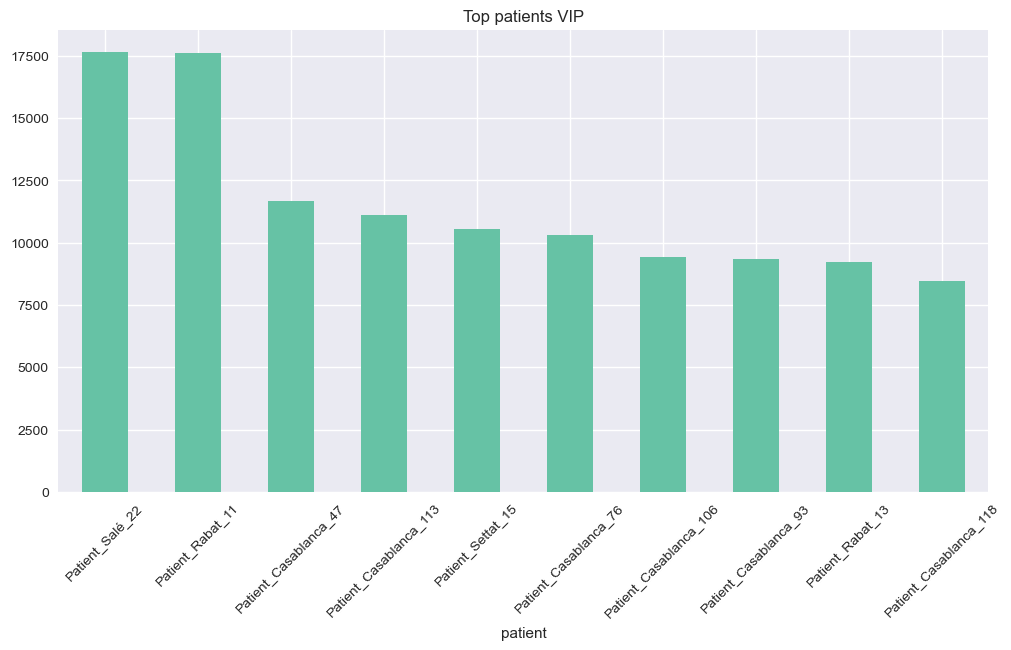

In [23]:
#Clients
#Top patients
df.groupby("patient")["ca"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top patients VIP")
plt.xticks(rotation=45)
plt.savefig("resultats/top_patients.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
import numpy as np
def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n+1)
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_value = gini(df.groupby("patient")["ca"].sum().values)

print("Indice de Gini :", gini_value)

Indice de Gini : 0.29942975703449615


In [25]:
# =========================
# 6. SUPPLY CHAIN ANALYSIS
# =========================

In [26]:
#Pharmacies

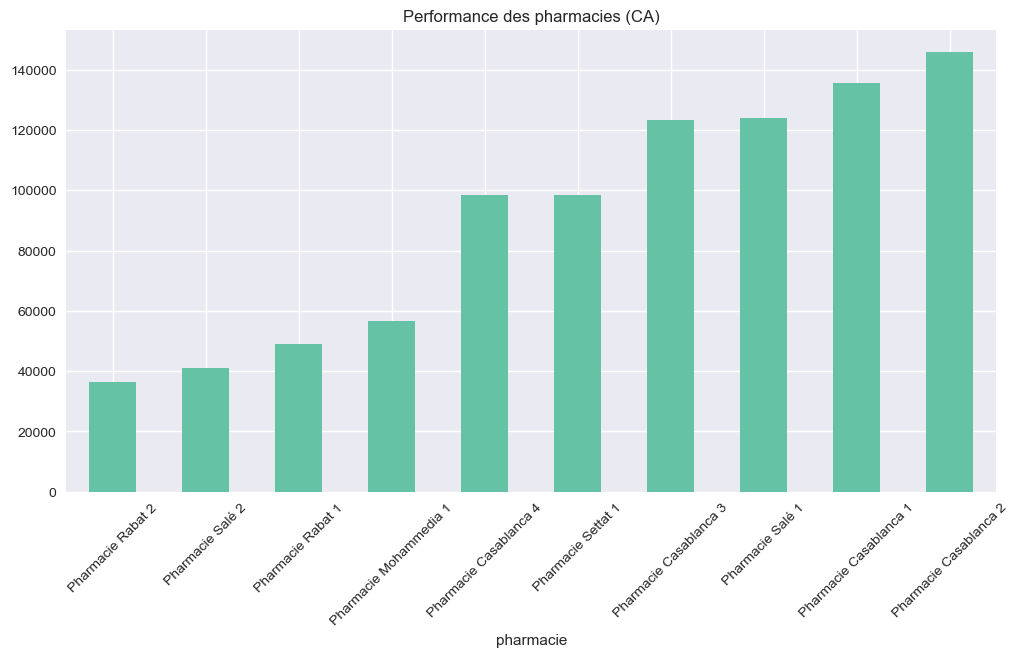

In [27]:
df_pharma = df.copy()

perf_pharma = df_pharma.groupby("pharmacie").agg(
    ca=("ca", "sum"),
    profit=("profit", "sum"),
    nb_ventes=("id_vente", "count"),
    quantite_totale=("quantite", "sum"),
    stock_moyen=("stock", "mean")
)

perf_pharma["ca_moyen_vente"] = perf_pharma["ca"] / perf_pharma["nb_ventes"]

perf_pharma.sort_values("ca", ascending=False).head(10)

perf_pharma["ca"].sort_values().plot(kind="bar")
plt.title("Performance des pharmacies (CA)")
plt.xticks(rotation=45)
plt.savefig("resultats/performance_pharmacies.png", dpi=300, bbox_inches="tight")

plt.show()
perf_pharma.to_excel("resultats/performance_pharmacies.xlsx")


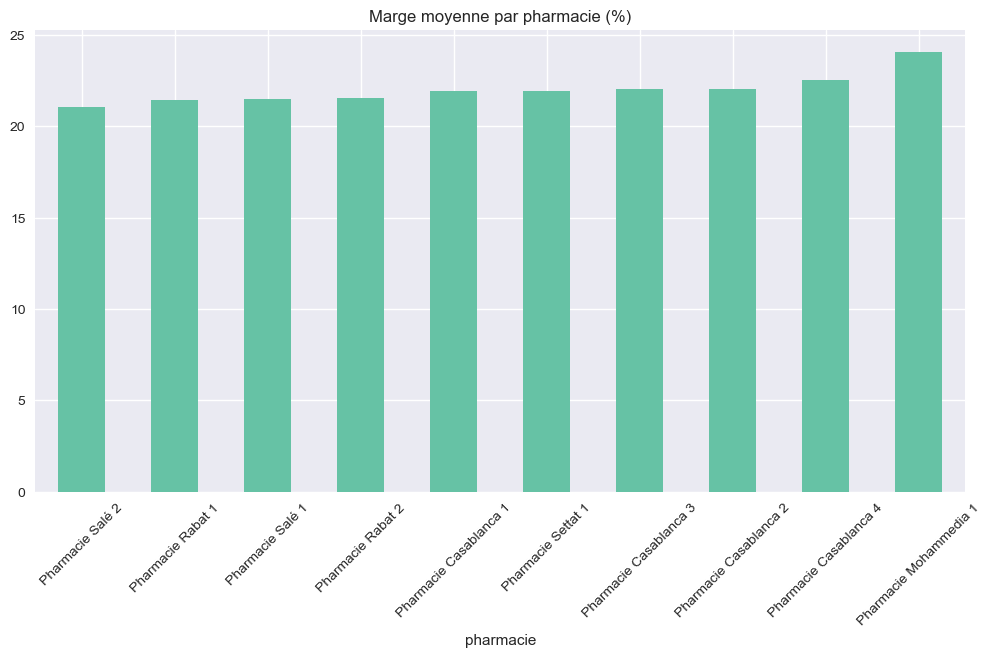

In [28]:

kpi_pharma = df.groupby("pharmacie").agg(
    ca=("ca", "sum"),
    profit=("profit", "sum"),
    nb_ventes=("id_vente", "count"),
    stock_moyen=("stock", "mean")
)

kpi_pharma["marge_moyenne"] = (kpi_pharma["profit"] / kpi_pharma["ca"]) * 100

kpi_pharma.sort_values("marge_moyenne", ascending=False).head(10)

kpi_pharma["marge_moyenne"].sort_values().plot(kind="bar")
plt.title("Marge moyenne par pharmacie (%)")
plt.xticks(rotation=45)
plt.savefig("resultats/marge_moyenne_pharmacies.png", dpi=300, bbox_inches="tight")
plt.show()
kpi_pharma.to_excel("resultats/kpi_pharmacies.xlsx")
#On mesure la rentabilité réelle des pharmacies via la marge moyenne, 
# qui indique la part du profit dans le chiffre d’affaires.

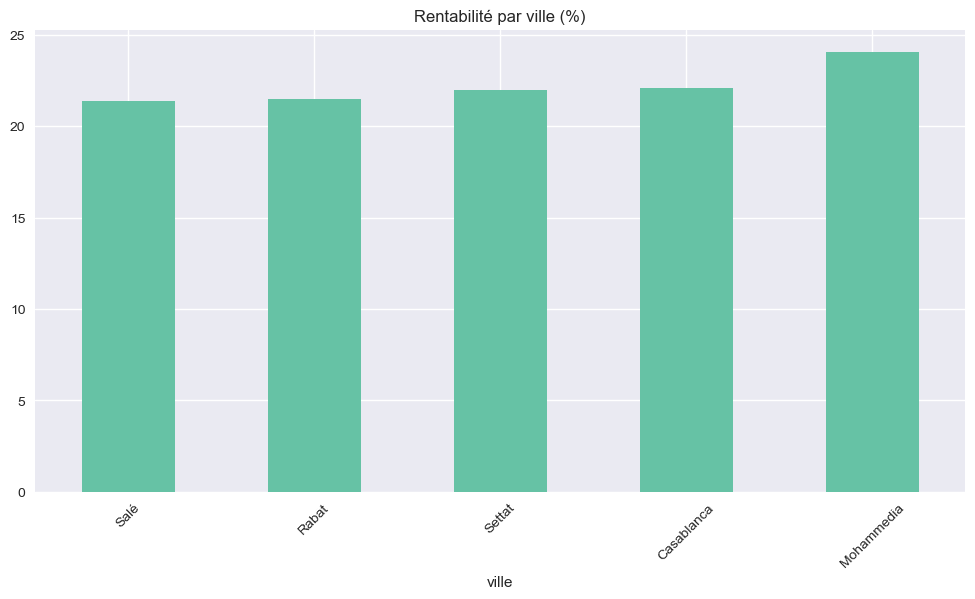

In [29]:
kpi_ville = df.groupby("ville").agg(
    ca=("ca", "sum"),
    profit=("profit", "sum"),
    nb_ventes=("id_vente", "count")
)

kpi_ville["rentabilite"] = (kpi_ville["profit"] / kpi_ville["ca"]) * 100

kpi_ville.sort_values("rentabilite", ascending=False)

kpi_ville["rentabilite"].sort_values().plot(kind="bar")
plt.title("Rentabilité par ville (%)")
plt.xticks(rotation=45)
plt.savefig("resultats/rentabilite_ville.png", dpi=300, bbox_inches="tight")
plt.show()
kpi_ville.to_excel("resultats/kpi_villes.xlsx")


In [30]:
#grossistes

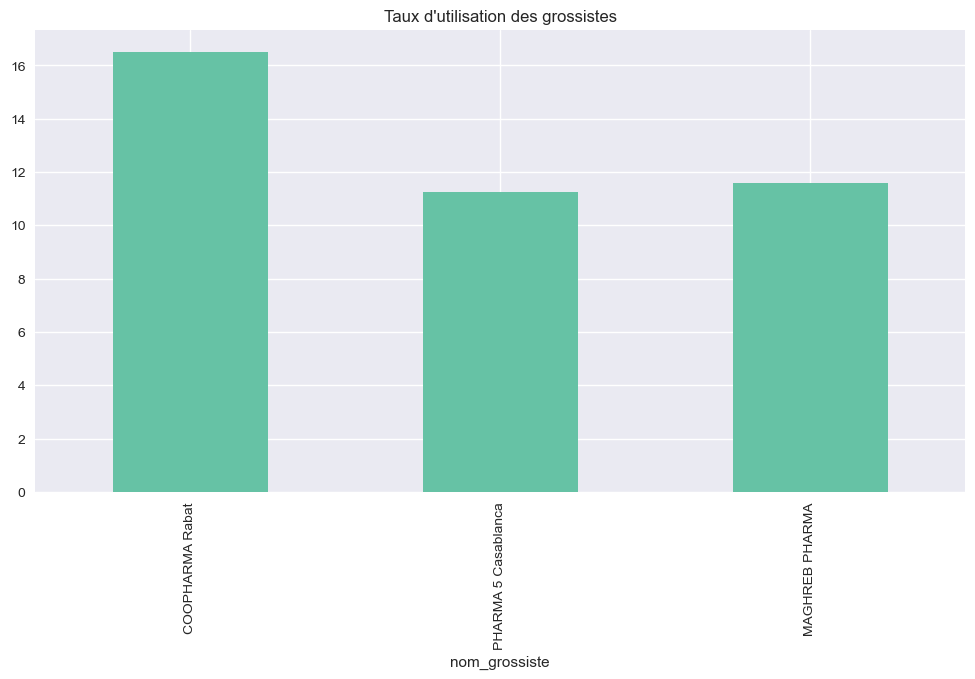

In [31]:
query_grossistes = """
SELECT 
    g.nom_grossiste,
    COUNT(DISTINCT p.id_pharmacie) as nb_pharmacies,
    SUM(a.quantite_livree) as total_livre,
    g.capacite_livraison,
    (SUM(a.quantite_livree)*100.0/g.capacite_livraison) as taux_utilisation
FROM grossistes g
JOIN approvisionnement a ON g.id_grossiste = a.id_grossiste
JOIN pharmacies p ON a.id_pharmacie = p.id_pharmacie
GROUP BY g.id_grossiste
"""

df_grossistes = pd.read_sql_query(query_grossistes, conn)

df_grossistes["livre_par_pharmacie"] = (
    df_grossistes["total_livre"] / df_grossistes["nb_pharmacies"]
)
df_grossistes.set_index("nom_grossiste")["taux_utilisation"].plot(kind="bar")
plt.title("Taux d'utilisation des grossistes") 
plt.savefig("resultats/taux_utilisation_grossistes.png", dpi=300, bbox_inches="tight")
plt.show()
df_grossistes.to_excel("resultats/grossistes.xlsx")

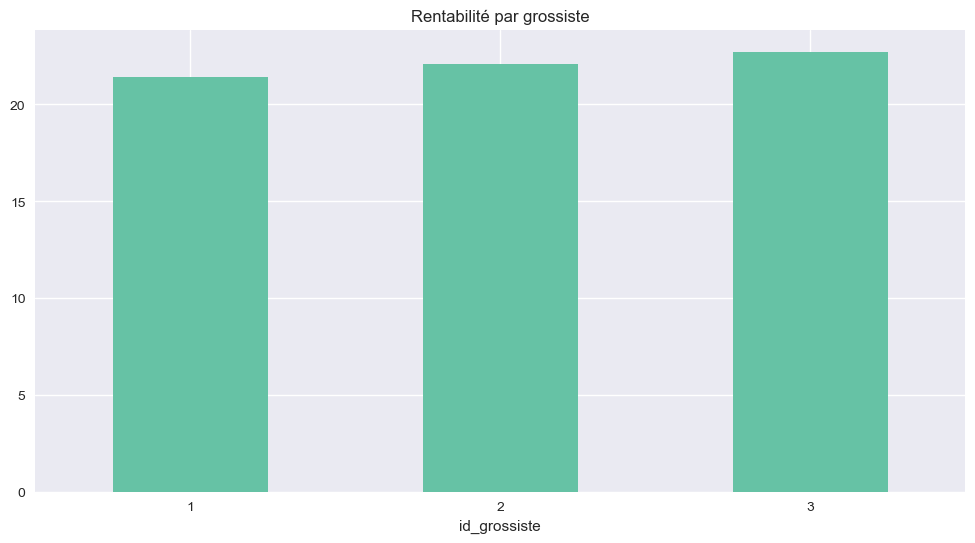

NameError: name 'comparison' is not defined

In [32]:
#COMPARAISON GROSSISTES vs PHARMACIES pour voir si la chaîne logistique influence la performance.

df["ca"] = df["prix_vente"]
df["cout"] = df["pfht"] * df["quantite"]
df["profit"] = df["ca"] - df["cout"]

df_gross_pharma = df.groupby(["id_grossiste", "pharmacie"]).agg(
    ca=("ca", "sum"),
    profit=("profit", "sum"),
    nb_ventes=("id_vente", "count")
).reset_index()

gross_perf = df.groupby("id_grossiste").agg(
    ca=("ca", "sum"),
    profit=("profit", "sum"),
    nb_ventes=("id_vente", "count")
)

gross_perf["rentabilite"] = (gross_perf["profit"] / gross_perf["ca"]) * 100

gross_perf["rentabilite"].plot(kind="bar")
plt.title("Rentabilité par grossiste")
plt.xticks(rotation=0) 
plt.savefig("resultats/rentabilite_grossistes.png", dpi=300, bbox_inches="tight")
plt.show()
comparison.to_excel("resultats/comparaison_grossistes.xlsx")


In [ ]:
#risque rupture

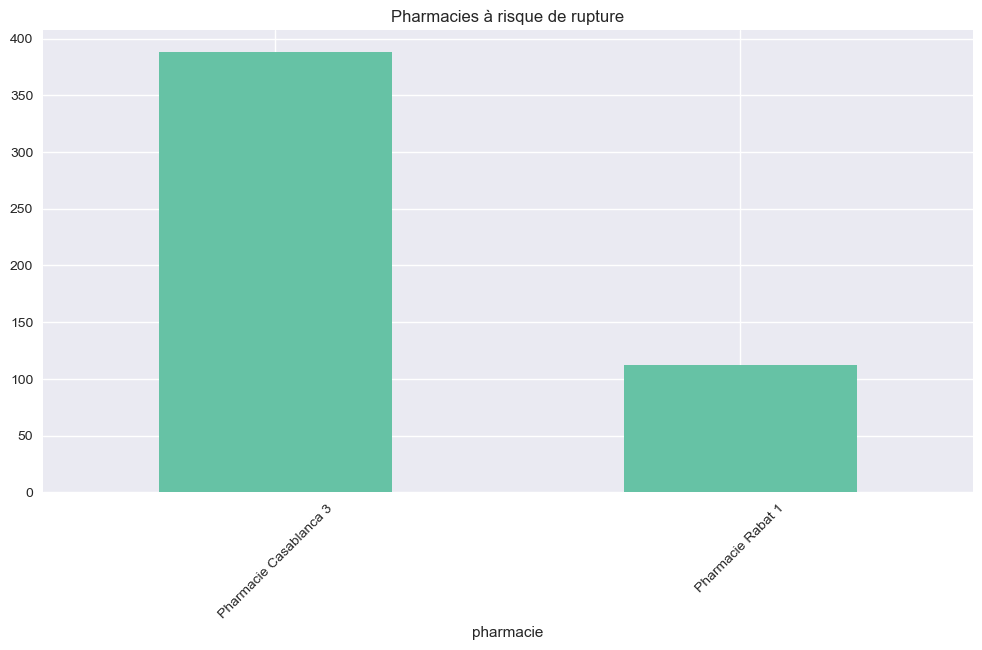

In [ ]:
seuil_stock = df["stock"].quantile(0.25)

ruptures = df[df["stock"] < seuil_stock]

ruptures.groupby("pharmacie")["stock"].min().sort_values()

ruptures["pharmacie"].value_counts().plot(kind="bar")
plt.title("Pharmacies à risque de rupture")
plt.xticks(rotation=45) 
plt.savefig("resultats/rupture_pharmacies.png", dpi=300, bbox_inches="tight")
plt.show()
ruptures.to_excel("resultats/ruptures_stock.xlsx")

In [ ]:
# =========================
# 7. INSIGHTS BUSINESS
# =========================

In [ ]:
print("CA total :", df["ca"].sum())
print("Profit total :", df["profit"].sum())

print("Ville top :", df.groupby("ville")["ca"].sum().idxmax())
print("Région top :", df.groupby("region")["ca"].sum().idxmax())
print("Produit top :", df.groupby("medicament")["ca"].sum().idxmax())
print("Client VIP :", df.groupby("patient")["ca"].sum().idxmax())

CA total : 908799.52
Profit total : 200128.88
Ville top : Casablanca
Région top : Casablanca-Settat
Produit top : Votrient 200mg sol (1)
Client VIP : Patient_Salé_22


In [ ]:


with open("resultats/kpi_resume.txt", "w", encoding="utf-8") as f:

    f.write(f"CA total : {df['ca'].sum()}\n")
    f.write(f"Profit total : {df['profit'].sum()}\n")
    f.write(f"Nombre ventes : {df['id_vente'].count()}\n")

In [ ]:
df.to_excel("resultats/dataset_final.xlsx", index=False)

In [ ]:
print("Tous les résultats ont été sauvegardés dans le dossier resultats/")

Tous les résultats ont été sauvegardés dans le dossier resultats/
